<>:215: SyntaxWarning: invalid escape sequence '\ '
<>:215: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3900/1969603564.py:215: SyntaxWarning: invalid escape sequence '\ '
  rf"$\mathbf{{{title.replace(' ', '\ ')}}}$",


[-15.         -14.3877551  -13.7755102  -13.16326531 -12.55102041
 -11.93877551 -11.32653061 -10.71428571 -10.10204082  -9.48979592
  -8.87755102  -8.26530612  -7.65306122  -7.04081633  -6.42857143
  -5.81632653  -5.20408163  -4.59183673  -3.97959184  -3.36734694
  -2.75510204  -2.14285714  -1.53061224  -0.91836735  -0.30612245
   0.30612245   0.91836735   1.53061224   2.14285714   2.75510204
   3.36734694   3.97959184   4.59183673   5.20408163   5.81632653
   6.42857143   7.04081633   7.65306122   8.26530612   8.87755102
   9.48979592  10.10204082  10.71428571  11.32653061  11.93877551
  12.55102041  13.16326531  13.7755102   14.3877551   15.        ]
Loading sentence-transformers/all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

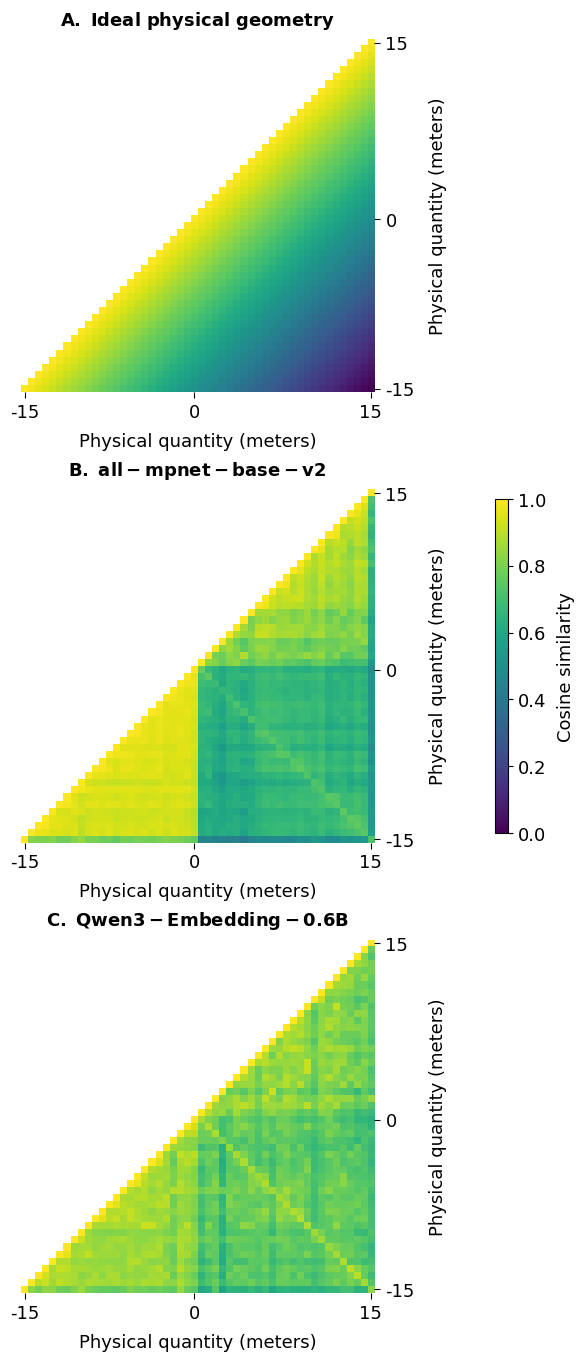

In [ ]:
# figure1.py
#
# Figure 1 for:
# "Can Embedding Models Measure?"
#
# Produces a publication-quality figure with
#
#   A. Ideal physical geometry
#   B. MiniLM-L6-v2
#   C. Qwen3-Embedding-0.6B
#
# using logarithmically spaced physical quantities.

import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import kendalltau


# ---------------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------------

UNIT = "meter"

VALUES = np.logspace(-2, 2, 40)
VALUES = np.linspace(-15, 15, 50)
print(VALUES)

MODELS = [
    ("A. Ideal physical geometry", None),
    ("B. all-mpnet-base-v2", "sentence-transformers/all-mpnet-base-v2"),
    ("C. Qwen3-Embedding-0.6B", "Qwen/Qwen3-Embedding-0.6B"),
]

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
})


# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------

def format_unit(v, unit):
    unit_name = unit if abs(v) == 1 else unit + "s"
    return f"{v:g} {unit_name}"


def ideal_similarity(values):
    """
    Gold-standard similarity.

    Similarity decreases linearly with physical distance.
    """

    values = np.asarray(values)

    D = np.abs(values[:, None] - values[None, :])

    D /= D.max()

    return 1.0 - D


def pairwise_accuracy(anchor_similarity):

    correct = 0
    total = 0

    n = len(anchor_similarity)

    for i in range(n):
        for j in range(i + 1, n):

            total += 1

            if anchor_similarity[i] > anchor_similarity[j]:
                correct += 1

    return correct / total


def evaluate(similarity_matrix):

    anchor = similarity_matrix[0]

    tau, _ = kendalltau(
        np.arange(len(anchor)),
        -anchor,
    )

    acc = pairwise_accuracy(anchor)

    return tau, acc


def build_embedding_similarity(model_name):

    print(f"Loading {model_name}")

    model = SentenceTransformer(
        model_name,
        trust_remote_code=True,
    )

    texts = [
        format_unit(v, UNIT)
        for v in VALUES
    ]

    emb = model.encode(
        texts,
        normalize_embeddings=True,
    )

    return cosine_similarity(emb)


# ---------------------------------------------------------------------
# BUILD MATRICES
# ---------------------------------------------------------------------

matrices = []

for title, model_name in MODELS:

    if model_name is None:
        sim = ideal_similarity(VALUES)
    else:
        sim = build_embedding_similarity(model_name)

    tau, acc = evaluate(sim)

    matrices.append((title, sim, tau, acc))


# ---------------------------------------------------------------------
# TICKS
# ---------------------------------------------------------------------

tick_values = np.array([
    -15,
    0,
    15,
])

tick_positions = [
    np.argmin(np.abs(VALUES - t))
    for t in tick_values
]

tick_labels = [
    "-15",
    "0",
    "15"
]

"""
tick_labels = [round(v,1) for v in VALUES[::2]]
tick_positions = [
    np.argmin(np.abs(VALUES - t))
    for t in VALUES[::2]
]
"""
# ---------------------------------------------------------------------
# FIGURE
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(7.5, 13.5),
    constrained_layout=True,
)

images = []

for ax, (title, sim, tau, acc) in zip(axes, matrices):

    # -------------------------------------------------------------
    # Mask the upper triangle, keeping the diagonal
    # -------------------------------------------------------------

    mask = np.triu(
        np.ones_like(sim, dtype=bool),
        k=1,
    ).T

    sim_masked = np.ma.array(
        sim,
        mask=mask,
    )

    im = ax.imshow(
        sim_masked,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    images.append(im)

    # -------------------------------------------------------------
    # Title
    # -------------------------------------------------------------

    ax.set_title(
        rf"$\mathbf{{{title.replace(' ', '\ ')}}}$",
        pad=10,
    )

    # -------------------------------------------------------------
    # X axis — bottom edge of the filled triangle
    # -------------------------------------------------------------

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel(
        "Physical quantity (meters)",
        labelpad=8,
    )

    # -------------------------------------------------------------
    # Y axis — RIGHT edge of the filled triangle
    # -------------------------------------------------------------

    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)

    ax.set_ylabel(
        "Physical quantity (meters)",
        labelpad=10,
    )

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    # -------------------------------------------------------------
    # Remove the rectangular box completely
    # -------------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_visible(False)

    # -------------------------------------------------------------
    # Only ticks on the two meaningful sides
    # -------------------------------------------------------------

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        top=False,
        labelbottom=True,
        length=4,
        pad=4,
    )

    ax.tick_params(
        axis="y",
        which="both",
        left=False,
        right=True,
        labelleft=False,
        labelright=True,
        length=4,
        pad=4,
    )

    # -------------------------------------------------------------
    # White background for the masked region
    # -------------------------------------------------------------

    ax.set_facecolor("white")

    # Keep the matrix exactly within its natural boundaries
    ax.set_xlim(-0.5, len(VALUES) - 0.5)
    ax.set_ylim(-0.5, len(VALUES) - 0.5)


# ---------------------------------------------------------------------
# COLORBAR
# ---------------------------------------------------------------------

# Put the colorbar farther away from the right-hand y-axis labels
# so the two visual elements don't compete.

cbar = fig.colorbar(
    images[-1],
    ax=axes,
    fraction=0.025,
    pad=0.09,
    aspect=25,
)

cbar.set_label(
    "Cosine similarity",
    labelpad=8,
)


# ---------------------------------------------------------------------
# SAVE
# ---------------------------------------------------------------------

plt.savefig(
    "figure1.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.savefig(
    "figure1.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()